Preprocessing

In [11]:
import re
import pandas as pd

columns = []

with open("KDDTrain+.arff", "r") as f:
    for line in f:
        if line.lower().startswith("@attribute"):
            parts = re.split(r"\s+", line.strip(), maxsplit = 2)
            col_name = parts[1].strip("'\"")
            columns.append(col_name)

# KDD .txt file has one extra column for difficulty
columns.append("difficulty")

print("Number of columns:", len(columns))
for i, col in enumerate(columns, 1):
    print(f"{i: 2}. {col}")

Number of columns: 43
 1. duration
 2. protocol_type
 3. service
 4. flag
 5. src_bytes
 6. dst_bytes
 7. land
 8. wrong_fragment
 9. urgent
 10. hot
 11. num_failed_logins
 12. logged_in
 13. num_compromised
 14. root_shell
 15. su_attempted
 16. num_root
 17. num_file_creations
 18. num_shells
 19. num_access_files
 20. num_outbound_cmds
 21. is_host_login
 22. is_guest_login
 23. count
 24. srv_count
 25. serror_rate
 26. srv_serror_rate
 27. rerror_rate
 28. srv_rerror_rate
 29. same_srv_rate
 30. diff_srv_rate
 31. srv_diff_host_rate
 32. dst_host_count
 33. dst_host_srv_count
 34. dst_host_same_srv_rate
 35. dst_host_diff_srv_rate
 36. dst_host_same_src_port_rate
 37. dst_host_srv_diff_host_rate
 38. dst_host_serror_rate
 39. dst_host_srv_serror_rate
 40. dst_host_rerror_rate
 41. dst_host_srv_rerror_rate
 42. class
 43. difficulty


In [12]:
train_df = pd.read_csv("KDDTrain+.txt", names = columns)
test_df  = pd.read_csv("KDDTest+.txt", names = columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [13]:
if "class" in train_df.columns: train_df.rename (columns = {"class": "label"}, inplace = True)
if "class" in test_df.columns:  test_df.rename  (columns = {"class": "label"}, inplace = True)

# drop difficulty : not a real feature for prediction
train_df.drop(columns = ["difficulty"], inplace = True)
test_df.drop(columns = ["difficulty"],  inplace = True)

print(train_df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10                    0.05   


In [14]:
train_df["label"] = (train_df["label"] != "normal").astype(int)
test_df["label"]  = (test_df["label"]  != "normal").astype(int)

print("Train label counts:\n", train_df["label"].value_counts())
print("\nTest label counts:\n", test_df["label"].value_counts())

Train label counts:
 0    67343
1    58630
Name: label, dtype: int64

Test label counts:
 1    12833
0     9711
Name: label, dtype: int64


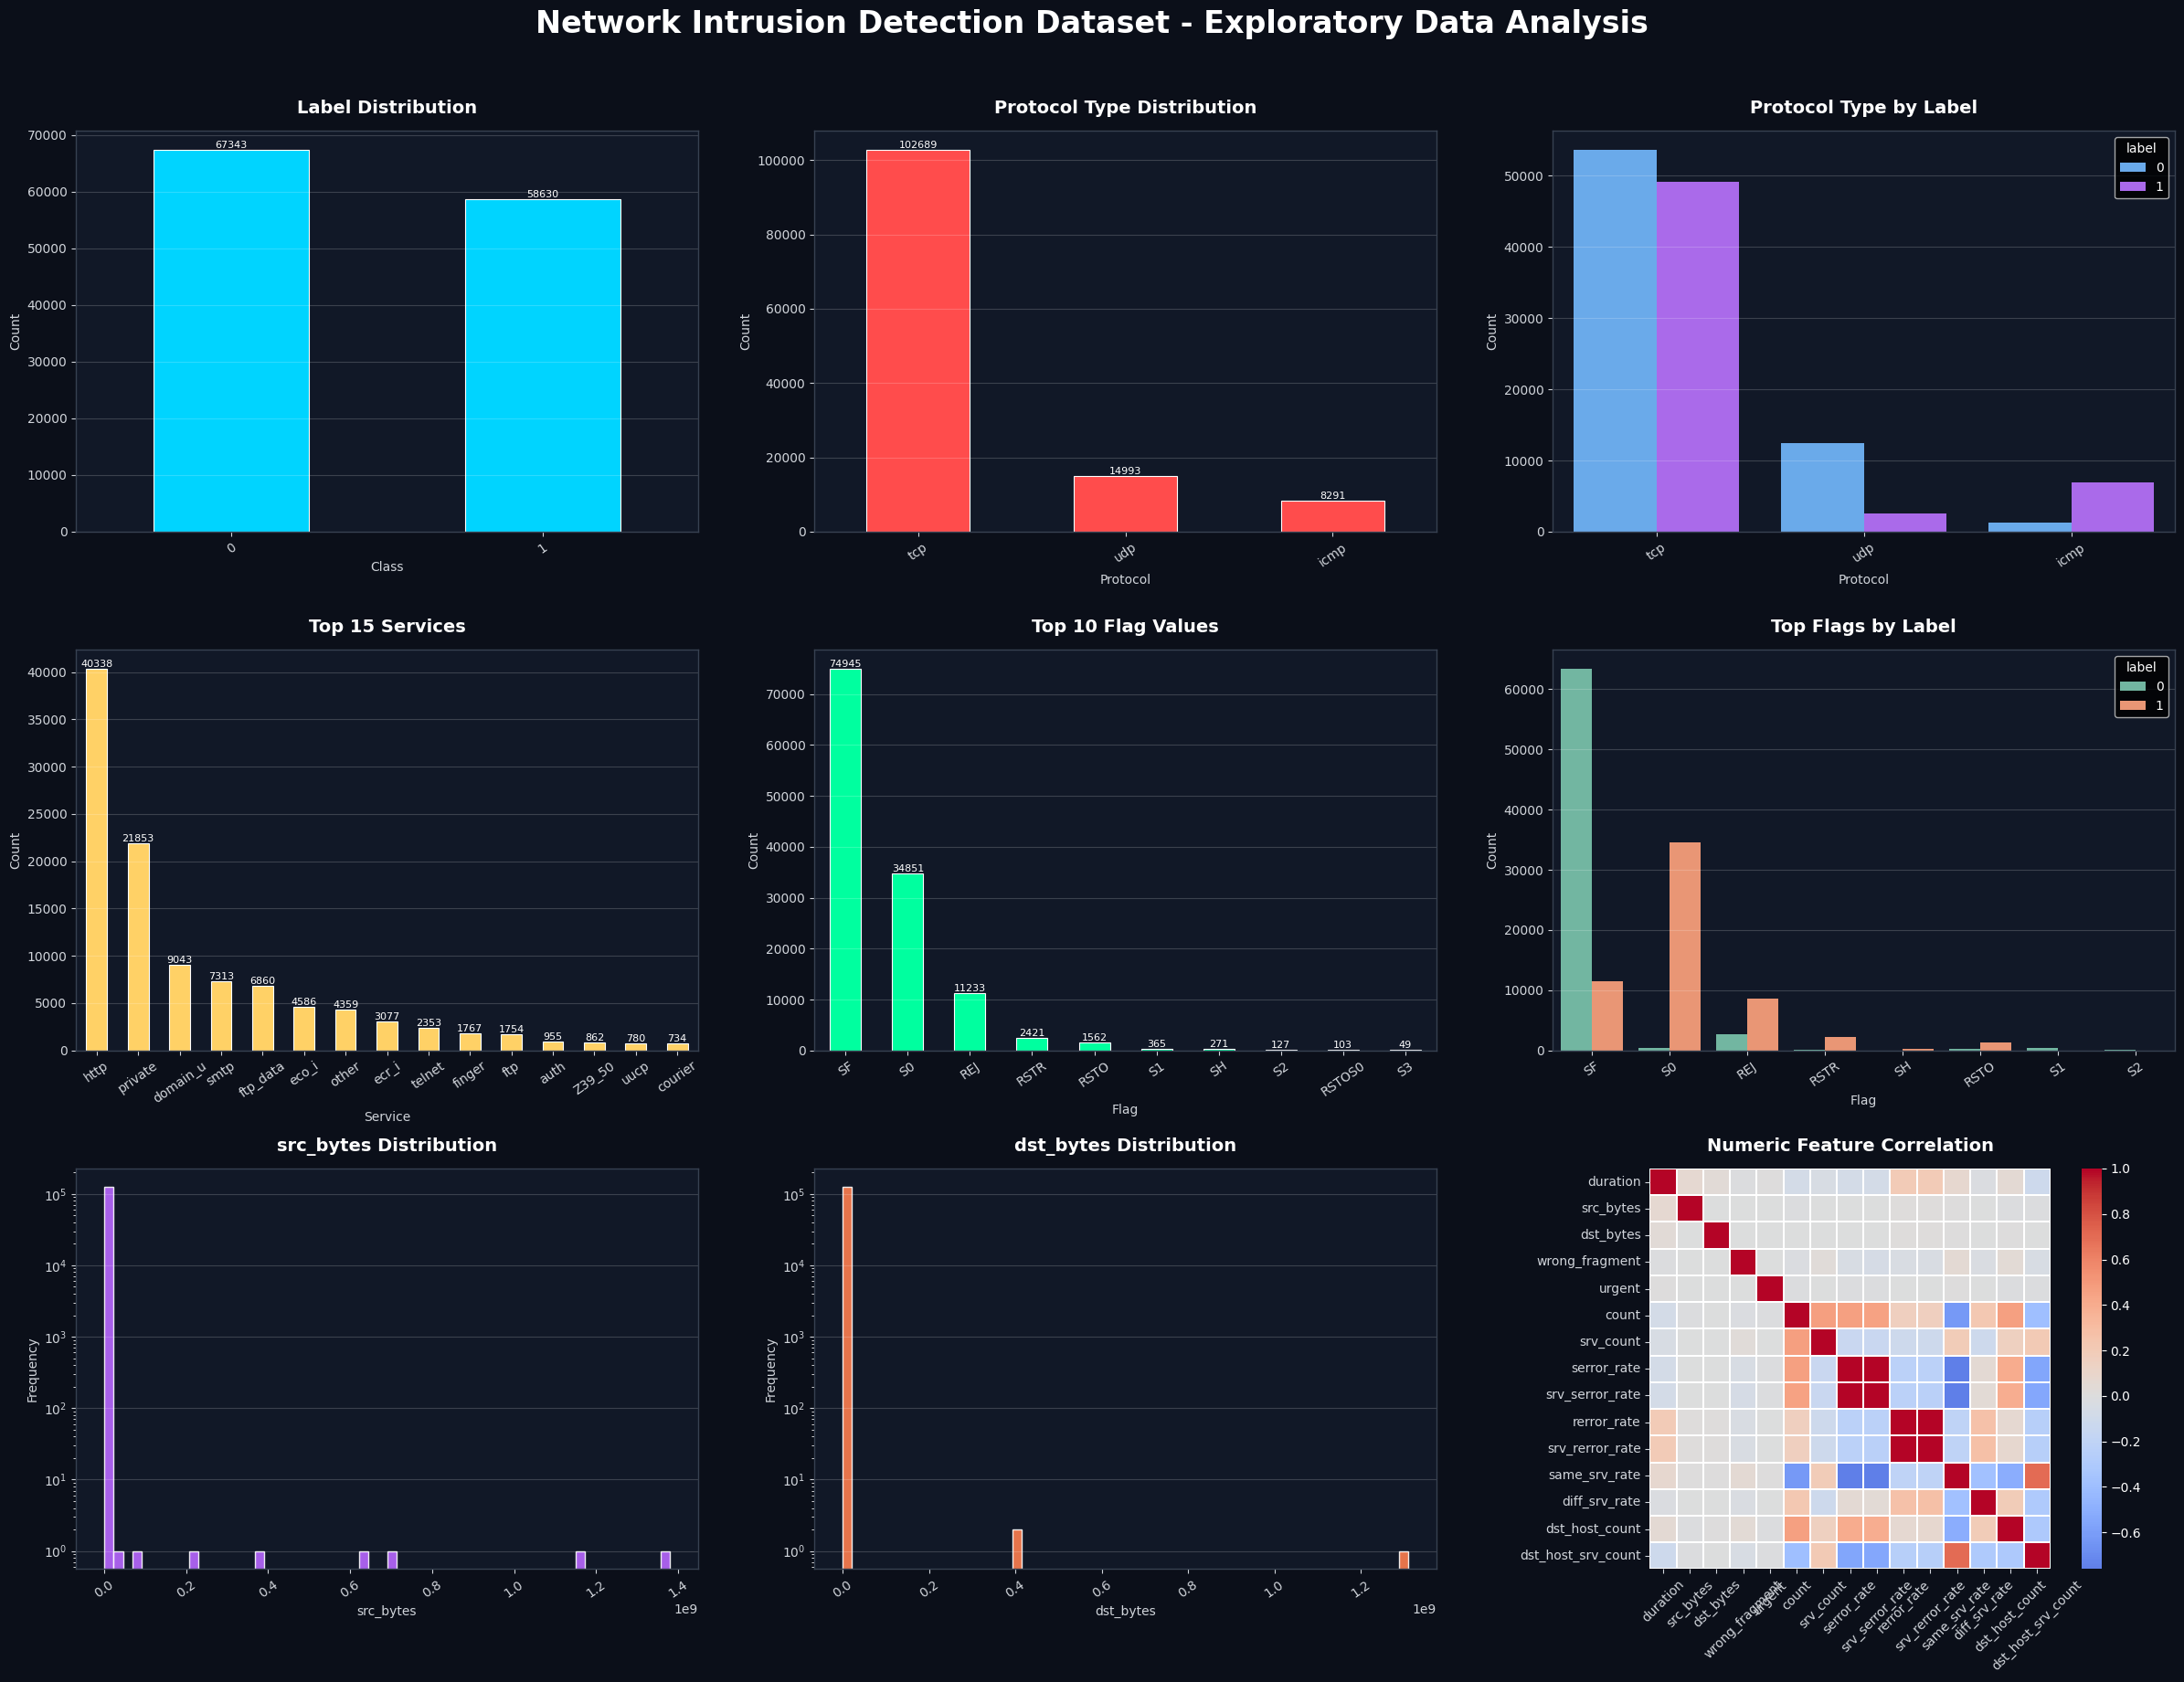

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

eda_df = train_df.copy()

label_col = "label"

fig, axes = plt.subplots(3, 3, figsize = (24, 18))
fig.patch.set_facecolor("#0b0f19")

colors = [
    "#00d4ff",
    "#ff4c4c",
    "#00ff9f",
    "#ffd166",
    "#b967ff",
    "#ff7f50",
    "#4ade80",
    "#f472b6",
    "#38bdf8"
]

def style_ax(ax, title, xlabel = "", ylabel = "Count"):
    ax.set_facecolor("#111827")
    ax.set_title(title, fontsize = 14, fontweight = "bold", color = "white", pad = 14)
    ax.set_xlabel(xlabel, fontsize = 10, color = "#d1d5db")
    ax.set_ylabel(ylabel, fontsize = 10, color = "#d1d5db")
    ax.tick_params(axis = "x", colors = "#d1d5db", rotation = 35)
    ax.tick_params(axis = "y", colors = "#d1d5db")
    ax.grid(axis = "y", alpha = 0.18, color = "white")

    for spine in ax.spines.values():
        spine.set_color("#374151")
        spine.set_linewidth(1)

def add_bar_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()

        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height)}",
                ha = "center",
                va = "bottom",
                fontsize = 8,
                color = "white"
            )

label_counts = eda_df[label_col].value_counts()

label_counts.plot(
    kind = "bar",
    ax = axes[0, 0],
    color = colors[0],
    edgecolor = "white",
    linewidth = 0.8
)

style_ax(axes[0, 0], "Label Distribution", "Class")
add_bar_labels(axes[0, 0])

protocol_counts = eda_df["protocol_type"].value_counts()

protocol_counts.plot(
    kind = "bar",
    ax = axes[0, 1],
    color = colors[1],
    edgecolor = "white",
    linewidth = 0.8
)

style_ax(axes[0, 1], "Protocol Type Distribution", "Protocol")
add_bar_labels(axes[0, 1])

sns.countplot(
    data = eda_df,
    x = "protocol_type",
    hue = label_col,
    ax = axes[0, 2],
    palette = "cool"
)

style_ax(axes[0, 2], "Protocol Type by Label", "Protocol")

service_counts = eda_df["service"].value_counts().head(15)

service_counts.plot(
    kind = "bar",
    ax = axes[1, 0],
    color = colors[3],
    edgecolor = "white",
    linewidth = 0.8
)

style_ax(axes[1, 0], "Top 15 Services", "Service")
add_bar_labels(axes[1, 0])

flag_counts = eda_df["flag"].value_counts().head(10)

flag_counts.plot(
    kind = "bar",
    ax = axes[1, 1],
    color = colors[2],
    edgecolor = "white",
    linewidth = 0.8
)

style_ax(axes[1, 1], "Top 10 Flag Values", "Flag")
add_bar_labels(axes[1, 1])

top_flags = eda_df["flag"].value_counts().head(8).index
flag_df = eda_df[eda_df["flag"].isin(top_flags)]

sns.countplot(
    data = flag_df,
    x = "flag",
    hue = label_col,
    ax = axes[1, 2],
    palette = "Set2"
)

style_ax(axes[1, 2], "Top Flags by Label", "Flag")

eda_df["src_bytes"].plot(
    kind = "hist",
    bins = 60,
    ax = axes[2, 0],
    color = colors[4],
    edgecolor = "white",
    alpha = 0.9
)

style_ax(axes[2, 0], "src_bytes Distribution", "src_bytes", "Frequency")
axes[2, 0].set_yscale("log")

eda_df["dst_bytes"].plot(
    kind = "hist",
    bins = 60,
    ax = axes[2, 1],
    color = colors[5],
    edgecolor = "white",
    alpha = 0.9
)

style_ax(axes[2, 1], "dst_bytes Distribution", "dst_bytes", "Frequency")
axes[2, 1].set_yscale("log")

numeric_cols = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "dst_host_count",
    "dst_host_srv_count"
]

numeric_cols = [col for col in numeric_cols if col in eda_df.columns]

corr = eda_df[numeric_cols].corr()

sns.heatmap(
    corr,
    ax = axes[2, 2],
    cmap = "coolwarm",
    center = 0,
    square = True,
    linewidths = 0.2,
    cbar = True
)

axes[2, 2].set_facecolor("#111827")
axes[2, 2].set_title(
    "Numeric Feature Correlation",
    fontsize = 14,
    fontweight = "bold",
    color = "white",
    pad = 14
)

axes[2, 2].tick_params(axis = "x", colors = "#d1d5db", rotation = 45)
axes[2, 2].tick_params(axis = "y", colors = "#d1d5db", rotation = 0)

fig.suptitle(
    "Network Intrusion Detection Dataset - Exploratory Data Analysis",
    fontsize = 24,
    fontweight = "bold",
    color = "white",
    y = 1.02
)

plt.tight_layout()
plt.show()

In [16]:
X_train = train_df.drop(columns = ["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns = ["label"])
y_test = test_df["label"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (125973, 41)
X_test : (22544, 41)


In [17]:
categorical_cols = ["protocol_type", "service", "flag"]
numerical_cols   = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Number of numerical columns:", len(numerical_cols))

Categorical: ['protocol_type', 'service', 'flag']
Number of numerical columns: 38


Machine Learning

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

linear_preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), categorical_cols)
    ]
)

linear_preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['duration', 'src_bytes', 'dst_bytes', 'land',
                                  'wrong_fragment', 'urgent', 'hot',
                                  'num_failed_logins', 'logged_in',
                                  'num_compromised', 'root_shell',
                                  'su_attempted', 'num_root',
                                  'num_file_creations', 'num_shells',
                                  'num_access_files', 'num_outbound_cmds',
                                  'is_host_login', 'is_guest_login', 'count',
                                  'srv_count', 'serror_rate', 'srv_serror_rate',
                                  'rerror_rate', 'srv_rerror_rate',
                                  'same_srv_rate', 'diff_srv_rate',
                                  'srv_diff_host_rate', 'dst_host_count',
                                  'dst_host_srv_count', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag'])])

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

tree_preprocessor = ColumnTransformer(
    transformers = [
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

tree_preprocessor

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['duration', 'src_bytes', 'dst_bytes', 'land',
                                  'wrong_fragment', 'urgent', 'hot',
                                  'num_failed_logins', 'logged_in',
                                  'num_compromised', 'root_shell',
                                  'su_attempted', 'num_root',
                                  'num_file_creations', 'num_shells',
                                  'num_access_files', 'num_outbound_cmds',
                                  'is_host_login', 'is_guest_login', 'count',
                                  'srv_count', 'serror_rate', 'srv_serror_rate',
                                  'rerror_rate', 'srv_rerror_rate',
                                  'same_srv_rate', 'diff_srv_rate',
                                  'srv_diff_host_rate', 'dst_host_count',
                                  'dst_host_srv_count', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag'])])

In [20]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression

# log_model = Pipeline([
#     ("preprocessor", linear_preprocessor),
#     ("clf", LogisticRegression(max_iter = 1000))
# ])

# log_model

import random
import warnings
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning


def run_logreg_random_search(n_iter = 200):
    results = []
    seen = set()

    best_test_acc = 0
    best_C = 1

    i = 0
    attempts = 0

    while i < n_iter:
        attempts += 1

        # broad search, then search near best (C after some good results)
        if i < 50:
            C = 10 ** random.uniform(-4, 4)
        else:
            low = np.log10(best_C) - 1
            high = np.log10(best_C) + 1
            C = 10 ** random.uniform(low, high)

        solver = random.choice(["liblinear", "lbfgs"])
        class_weight = random.choice([None, "balanced"])
        max_iter = random.choice([2000, 3000, 5000])

        config = (
            round(C, 6),
            solver,
            class_weight,
            max_iter
        )

        if config in seen: continue

        seen.add(config)

        model = Pipeline([
            ("preprocessor", linear_preprocessor),
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(
                C = C,
                solver = solver,
                class_weight = class_weight,
                max_iter = max_iter,
                random_state = 42
            ))
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        results.append({
            "model": "LogisticRegression",
            "C": C,
            "solver": solver,
            "class_weight": class_weight,
            "max_iter": max_iter,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "gap": gap
        })

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_C = C

            print(
                f"new best at {i+1}/{n_iter} | "
                f"test_acc = {test_acc:.5f} | "
                f"train_acc = {train_acc:.5f} | "
                f"gap = {gap:.5f} | "
                f"C = {C:.6f} | "
                f"solver = {solver} | "
                f"class_weight = {class_weight}"
            )
        else:
            print(f"finished {i+1}/{n_iter}")

        i += 1

    df = pd.DataFrame(results)

    df = df.sort_values(
        by = ["test_acc", "gap", "train_acc"],
        ascending = [False, True, False]
    ).reset_index(drop=True)

    return df


logreg_results = run_logreg_random_search(n_iter = 200)
logreg_results.to_csv("logreg_results.csv", index = False)

print("\nTop 10 Logistic Regression Results:")
print(logreg_results.head(10))

new best at 1/200 | test_acc = 0.75417 | train_acc = 0.97415 | gap = 0.21998 | C = 4.439502 | solver = lbfgs | class_weight = None
new best at 2/200 | test_acc = 0.75510 | train_acc = 0.97525 | gap = 0.22015 | C = 3.825221 | solver = liblinear | class_weight = balanced
new best at 3/200 | test_acc = 0.75696 | train_acc = 0.97594 | gap = 0.21898 | C = 41.009016 | solver = lbfgs | class_weight = balanced
finished 4/200
finished 5/200
finished 6/200
finished 7/200
finished 8/200
finished 9/200
finished 10/200
finished 11/200
finished 12/200
finished 13/200
finished 14/200
finished 15/200
finished 16/200
finished 17/200
finished 18/200
finished 19/200
finished 20/200
finished 21/200
finished 22/200
finished 23/200
finished 24/200
finished 25/200
finished 26/200
finished 27/200
finished 28/200
finished 29/200
finished 30/200
finished 31/200
finished 32/200
finished 33/200
finished 34/200
finished 35/200
finished 36/200
finished 37/200
finished 38/200
finished 39/200
finished 40/200
finished

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# dt_model = Pipeline([
#     ("preprocessor", tree_preprocessor),
#     ("clf", DecisionTreeClassifier(
#         random_state = 42,
#         max_depth = 20,
#         min_samples_split = 10,
#         min_samples_leaf = 5
#     ))
# ])

# dt_model



def run_tree_random_search(n_iter = 200):
    results = []
    seen = set()

    best_test_acc = 0
    best_params = None

    i = 0

    while i < n_iter:
        if i < 50:
            max_depth = random.randint(2, 35)
            min_samples_split = random.randint(2, 40)
            min_samples_leaf = random.randint(1, 20)
            ccp_alpha = random.choice([0.0, 0.000001, 0.00001, 0.0001, 0.001, 0.01])
        else:
            # after we find decent trees, search closer to the best area
            max_depth = random.randint(
                max(2, best_params["max_depth"] - 5),
                min(40, best_params["max_depth"] + 5)
            )

            min_samples_split = random.randint(
                max(2, best_params["min_samples_split"] - 10),
                min(50, best_params["min_samples_split"] + 10)
            )

            min_samples_leaf = random.randint(
                max(1, best_params["min_samples_leaf"] - 5),
                min(25, best_params["min_samples_leaf"] + 5)
            )

            ccp_alpha = random.choice([
                best_params["ccp_alpha"],
                0.0,
                0.000001,
                0.00001,
                0.0001,
                0.001
            ])

        criterion = random.choice(["gini", "entropy", "log_loss"])
        splitter = random.choice(["best", "random"])

        config = (
            max_depth,
            min_samples_split,
            min_samples_leaf,
            criterion,
            splitter,
            ccp_alpha
        )

        if config in seen: continue

        seen.add(config)

        model = Pipeline([
            ("preprocessor", tree_preprocessor),
            ("clf", DecisionTreeClassifier(
                random_state = 42,
                max_depth = max_depth,
                min_samples_split = min_samples_split,
                min_samples_leaf = min_samples_leaf,
                criterion = criterion,
                splitter = splitter,
                ccp_alpha = ccp_alpha
            ))
        ])

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        results.append({
            "model": "DecisionTree",
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
            "criterion": criterion,
            "splitter": splitter,
            "ccp_alpha": ccp_alpha,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "gap": gap
        })

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_params = {
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "ccp_alpha": ccp_alpha
            }

            print(
                f"new best at {i+1}/{n_iter} | "
                f"test_acc = {test_acc:.5f} | "
                f"train_acc = {train_acc:.5f} | "
                f"gap = {gap:.5f} | "
                f"depth = {max_depth} | "
                f"split = {min_samples_split} | "
                f"leaf = {min_samples_leaf} | "
                f"ccp_alpha = {ccp_alpha}"
            )
        else:
            print(f"finished {i+1}/{n_iter}")

        i += 1

    df = pd.DataFrame(results)

    df = df.sort_values(
        by = ["test_acc", "gap", "train_acc"],
        ascending = [False, True, False]
    ).reset_index(drop = True)

    return df


tree_results = run_tree_random_search(n_iter = 200)
tree_results.to_csv("tree_results.csv", index=False)

print("\nTop 10 Decision Tree Results:")
print(tree_results.head(10))

new best at 1/200 | test_acc = 0.77493 | train_acc = 0.99786 | gap = 0.22294 | depth = 34 | split = 13 | leaf = 16 | ccp_alpha = 0.0
new best at 2/200 | test_acc = 0.79760 | train_acc = 0.99659 | gap = 0.19899 | depth = 17 | split = 33 | leaf = 8 | ccp_alpha = 0.0001
finished 3/200
finished 4/200
finished 5/200
finished 6/200
finished 7/200
finished 8/200
new best at 9/200 | test_acc = 0.79977 | train_acc = 0.99692 | gap = 0.19715 | depth = 31 | split = 32 | leaf = 7 | ccp_alpha = 1e-05
finished 10/200
new best at 11/200 | test_acc = 0.80545 | train_acc = 0.99767 | gap = 0.19222 | depth = 33 | split = 40 | leaf = 1 | ccp_alpha = 1e-05
finished 12/200
finished 13/200
finished 14/200
finished 15/200
finished 16/200
finished 17/200
finished 18/200
finished 19/200
finished 20/200
finished 21/200
finished 22/200
finished 23/200
finished 24/200
new best at 25/200 | test_acc = 0.80696 | train_acc = 0.99545 | gap = 0.18850 | depth = 13 | split = 12 | leaf = 9 | ccp_alpha = 1e-06
new best at 26

In [26]:
from sklearn.ensemble import RandomForestClassifier

# rf_model = Pipeline([
#     ("preprocessor", tree_preprocessor),
#     ("clf", RandomForestClassifier(
#         n_estimators = 200,
#         random_state = 42,
#         n_jobs = -1
#     ))
# ])

# rf_model

def run_rf_random_search(n_iter = 300):
    results = []
    seen = set()

    best_test_acc = 0
    best_params = None

    i = 0

    while i < n_iter:
        if i < 10:
            n_estimators = random.choice([50, 100, 150, 200])
            max_depth = random.choice([None, 10, 20, 30, 40])
            min_samples_split = random.randint(2, 20)
            min_samples_leaf = random.randint(1, 10)
        else:
            n_estimators = random.choice([
                best_params["n_estimators"],
                100,
                150,
                200,
                300
            ])

            if best_params["max_depth"] is None:
                max_depth = random.choice([None, 20, 30, 40])
            else:
                max_depth = random.randint(
                    max(5, best_params["max_depth"] - 10),
                    min(60, best_params["max_depth"] + 10)
                )

            min_samples_split = random.randint(
                max(2, best_params["min_samples_split"] - 5),
                min(30, best_params["min_samples_split"] + 5)
            )

            min_samples_leaf = random.randint(
                max(1, best_params["min_samples_leaf"] - 3),
                min(15, best_params["min_samples_leaf"] + 3)
            )

        max_features = random.choice(["sqrt", "log2", None])
        bootstrap = random.choice([True, False])

        if bootstrap == True:
            class_weight = random.choice([None, "balanced", "balanced_subsample"])
        else:
            class_weight = random.choice([None, "balanced"])

        config = (
            n_estimators,
            max_depth,
            min_samples_split,
            min_samples_leaf,
            max_features,
            bootstrap,
            class_weight
        )
        
        if config in seen: continue

        seen.add(config)

        model = Pipeline([
            ("preprocessor", tree_preprocessor),
            ("clf", RandomForestClassifier(
                n_estimators = n_estimators,
                max_depth = max_depth,
                min_samples_split = min_samples_split,
                min_samples_leaf = min_samples_leaf,
                max_features = max_features,
                bootstrap = bootstrap,
                class_weight = class_weight,
                random_state = 42,
                n_jobs = -1
            ))
        ])

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        results.append({
            "model": "RandomForest",
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
            "max_features": max_features,
            "bootstrap": bootstrap,
            "class_weight": class_weight,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "gap": gap
        })

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_params = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf
            }

            print(
                f"new best at {i+1}/{n_iter} | "
                f"test_acc = {test_acc:.5f} | "
                f"train_acc = {train_acc:.5f} | "
                f"gap = {gap:.5f} | "
                f"trees = {n_estimators} | "
                f"depth = {max_depth} | "
                f"split = {min_samples_split} | "
                f"leaf = {min_samples_leaf} | "
                f"features = {max_features} | "
                f"bootstrap = {bootstrap} | "
                f"class_weight = {class_weight}"
            )
        else:
            print(f"finished {i+1}/{n_iter}")

        i += 1

    df = pd.DataFrame(results)

    df = df.sort_values(
        by = ["test_acc", "gap", "train_acc"],
        ascending = [False, True, False]
    ).reset_index(drop = True)

    return df


rf_results = run_rf_random_search(n_iter = 300)
rf_results.to_csv("rf_results.csv", index = False)

print("\nTop 10 Random Forest Results:")
print(rf_results.head(10))

new best at 1/300 | test_acc = 0.76317 | train_acc = 0.99622 | gap = 0.23305 | trees = 200 | depth = 10 | split = 4 | leaf = 8 | features = sqrt | bootstrap = True | class_weight = None
new best at 2/300 | test_acc = 0.80487 | train_acc = 0.99844 | gap = 0.19357 | trees = 150 | depth = 30 | split = 19 | leaf = 10 | features = None | bootstrap = False | class_weight = balanced
finished 3/300
finished 4/300
new best at 5/300 | test_acc = 0.81512 | train_acc = 0.99917 | gap = 0.18405 | trees = 100 | depth = 20 | split = 14 | leaf = 3 | features = None | bootstrap = True | class_weight = balanced_subsample
finished 6/300
finished 7/300
finished 8/300
finished 9/300
new best at 10/300 | test_acc = 0.81521 | train_acc = 0.99906 | gap = 0.18386 | trees = 50 | depth = 30 | split = 14 | leaf = 4 | features = None | bootstrap = True | class_weight = None
finished 11/300
finished 12/300
finished 13/300
finished 14/300
finished 15/300
finished 16/300
new best at 17/300 | test_acc = 0.81587 | train

In [27]:
import pandas as pd

logreg_df = pd.read_csv("logreg_results.csv")
tree_df   = pd.read_csv("tree_results.csv")
rf_df     = pd.read_csv("rf_results.csv")

all_results = pd.concat([logreg_df, tree_df, rf_df], ignore_index = True)

all_results = all_results.sort_values(
    by = ["test_acc", "gap", "train_acc"],
    ascending = [False, True, False]
).reset_index(drop = True)

all_results.to_csv("all_models_results.csv", index = False)

print("Best overall result:")
print(all_results.head(10))

Best overall result:
          model   C solver class_weight  max_iter  train_acc  test_acc  \
0  DecisionTree NaN    NaN          NaN       NaN   0.996761  0.841954   
1  DecisionTree NaN    NaN          NaN       NaN   0.997587  0.839780   
2  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
3  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
4  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
5  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
6  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
7  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
8  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
9  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   

        gap  max_depth  min_samples_split  min_samples_leaf criterion  \
0  0.154808       28.0                8.0              11.0   entropy   
1  0.157807       

In [28]:
best = all_results.iloc[0]
print(best)

model_name = best["model"]

def clean_none(value):
    if pd.isna(value):  return None
    if value == "None": return None
    return value

def clean_bool(value):
    if value == True  or value == "True":  return True
    if value == False or value == "False": return False
    return value


if model_name == "LogisticRegression":
    final_model = Pipeline([
        ("preprocessor", linear_preprocessor),
        ("scaler", StandardScaler(with_mean = False)),
        ("clf", LogisticRegression(
            C = float(best["C"]),
            solver = best["solver"],
            class_weight = clean_none(best["class_weight"]),
            max_iter = int(best["max_iter"]),
            random_state = 42
        ))
    ])

elif model_name == "DecisionTree":
    final_model = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", DecisionTreeClassifier(
            max_depth = int(best["max_depth"]),
            min_samples_split = int(best["min_samples_split"]),
            min_samples_leaf = int(best["min_samples_leaf"]),
            criterion = best["criterion"],
            splitter = best["splitter"],
            ccp_alpha = float(best["ccp_alpha"]),
            random_state = 42
        ))
    ])

elif model_name == "RandomForest":
    final_model = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators = int(best["n_estimators"]),
            max_depth = None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
            min_samples_split = int(best["min_samples_split"]),
            min_samples_leaf = int(best["min_samples_leaf"]),
            max_features = clean_none(best["max_features"]),
            bootstrap = clean_bool(best["bootstrap"]),
            class_weight = clean_none(best["class_weight"]),
            random_state = 42,
            n_jobs = -1
        ))
    ])


model                DecisionTree
C                             NaN
solver                        NaN
class_weight                  NaN
max_iter                      NaN
train_acc                0.996761
test_acc                 0.841954
gap                      0.154808
max_depth                    28.0
min_samples_split             8.0
min_samples_leaf             11.0
criterion                 entropy
splitter                   random
ccp_alpha                 0.00001
n_estimators                  NaN
max_features                  NaN
bootstrap                     NaN
Name: 0, dtype: object


In [29]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_lo...
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('clf',
                 DecisionTreeClassifier(ccp_alpha=1e-05, criterion='entropy',
                                        max_depth=28, min_samples_leaf=11,
                                        min_samples_split=8, random_state=42,
                                        splitter='random'))])

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = final_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
    

Final Test Accuracy: 0.8419535131298793

Confusion Matrix:
 [[9388  323]
 [3240 9593]]

Report:
               precision    recall  f1-score   support

           0       0.74      0.97      0.84      9711
           1       0.97      0.75      0.84     12833

    accuracy                           0.84     22544
   macro avg       0.86      0.86      0.84     22544
weighted avg       0.87      0.84      0.84     22544



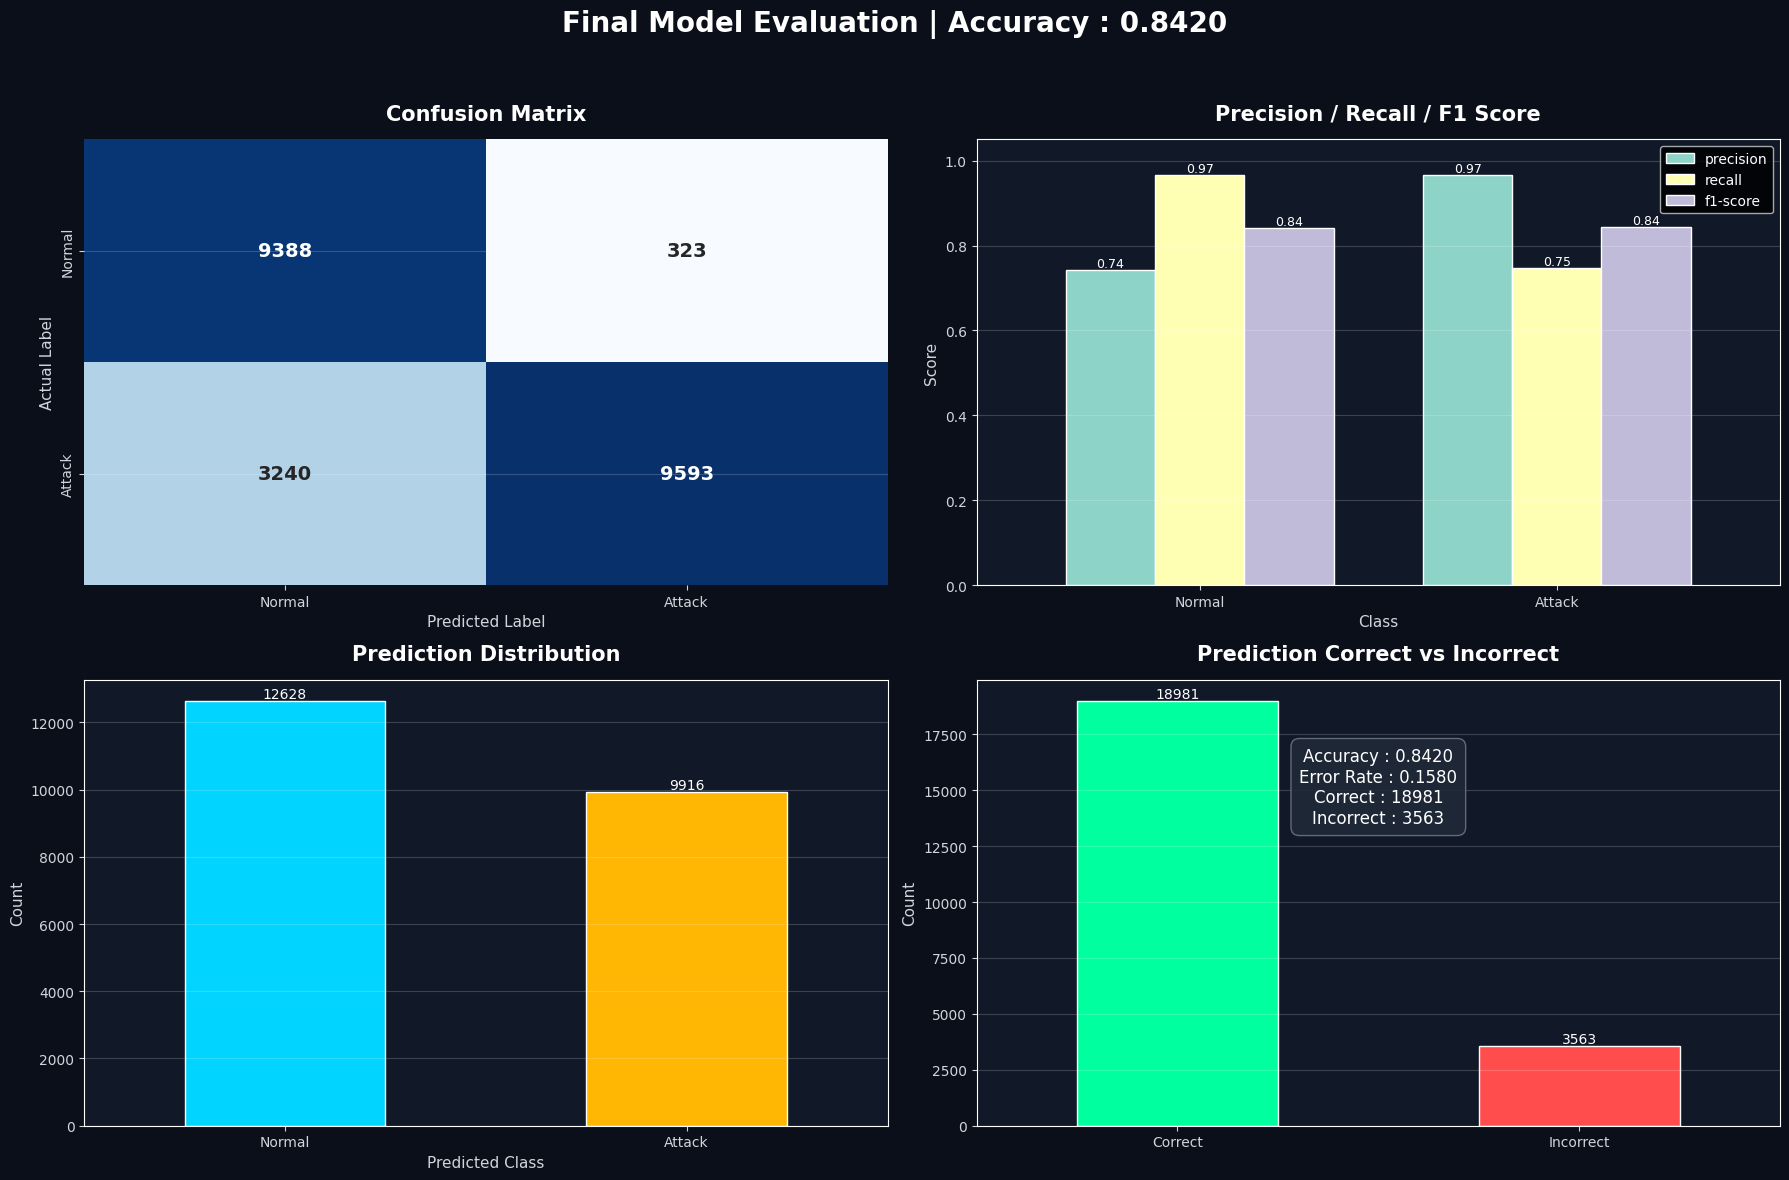

In [31]:
plt.style.use("dark_background")

final_accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels = [0, 1])

report_dict = classification_report(
    y_test,
    y_pred,
    labels = [0, 1],
    target_names = ["Normal", "Attack"],
    output_dict = True
)

report_df = pd.DataFrame(report_dict).transpose()

fig, axes = plt.subplots(2, 2, figsize = (18, 12))
fig.patch.set_facecolor("#0b0f19")

def style_ax(ax, title, xlabel = "", ylabel = ""):
    ax.set_facecolor("#111827")
    ax.set_title(title, fontsize = 15, fontweight = "bold", color = "white", pad = 14)
    ax.set_xlabel(xlabel, fontsize = 11, color = "#d1d5db")
    ax.set_ylabel(ylabel, fontsize = 11, color = "#d1d5db")
    ax.tick_params(axis = "x", colors = "#d1d5db", labelrotation = 0)
    ax.tick_params(axis = "y", colors = "#d1d5db")
    ax.grid(axis = "y", alpha = 0.18)

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["Normal", "Attack"],
    yticklabels = ["Normal", "Attack"],
    ax = axes[0, 0],
    cbar = False,
    annot_kws = {"fontsize": 14, "fontweight": "bold"}
)

style_ax(
    axes[0, 0],
    "Confusion Matrix",
    "Predicted Label",
    "Actual Label"
)

metric_df = report_df.loc[["Normal", "Attack"], ["precision", "recall", "f1-score"]]

metric_df.plot(
    kind = "bar",
    ax = axes[0, 1],
    edgecolor = "white",
    width = 0.75
)

style_ax(
    axes[0, 1],
    "Precision / Recall / F1 Score",
    "Class",
    "Score"
)

axes[0, 1].set_ylim(0, 1.05)

for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt = "%.2f", color = "white", fontsize = 9)

pred_counts = pd.Series(y_pred).value_counts().reindex([0, 1], fill_value = 0)
pred_counts.index = ["Normal", "Attack"]

pred_counts.plot(
    kind = "bar",
    ax = axes[1, 0],
    color = ["#00d4ff", "#ffb703"],
    edgecolor = "white"
)

style_ax(
    axes[1, 0],
    "Prediction Distribution",
    "Predicted Class",
    "Count"
)

for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, color = "white", fontsize = 10)

correct_count = (y_test == y_pred).sum()
incorrect_count = (y_test != y_pred).sum()

error_counts = pd.Series(
    [correct_count, incorrect_count],
    index = ["Correct", "Incorrect"]
)

error_counts.plot(
    kind = "bar",
    ax = axes[1, 1],
    color = ["#00ff9f", "#ff4c4c"],
    edgecolor = "white"
)

style_ax(
    axes[1, 1],
    "Prediction Correct vs Incorrect",
    "",
    "Count"
)

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, color = "white", fontsize = 10)

error_rate = 1 - final_accuracy

summary_text = (
    f"Accuracy : {final_accuracy:.4f}\n"
    f"Error Rate : {error_rate:.4f}\n"
    f"Correct : {correct_count}\n"
    f"Incorrect : {incorrect_count}"
)

axes[1, 1].text(
    0.5,
    0.85,
    summary_text,
    transform = axes[1, 1].transAxes,
    fontsize = 12,
    color = "white",
    ha = "center",
    va = "top",
    bbox = dict(
        boxstyle = "round,pad = 0.5",
        facecolor = "#1f2937",
        edgecolor = "#6b7280",
        alpha = 0.9
    )
)

fig.suptitle(
    f"Final Model Evaluation | Accuracy : {final_accuracy:.4f}",
    fontsize = 20,
    fontweight = "bold",
    color = "white"
)

plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.show()

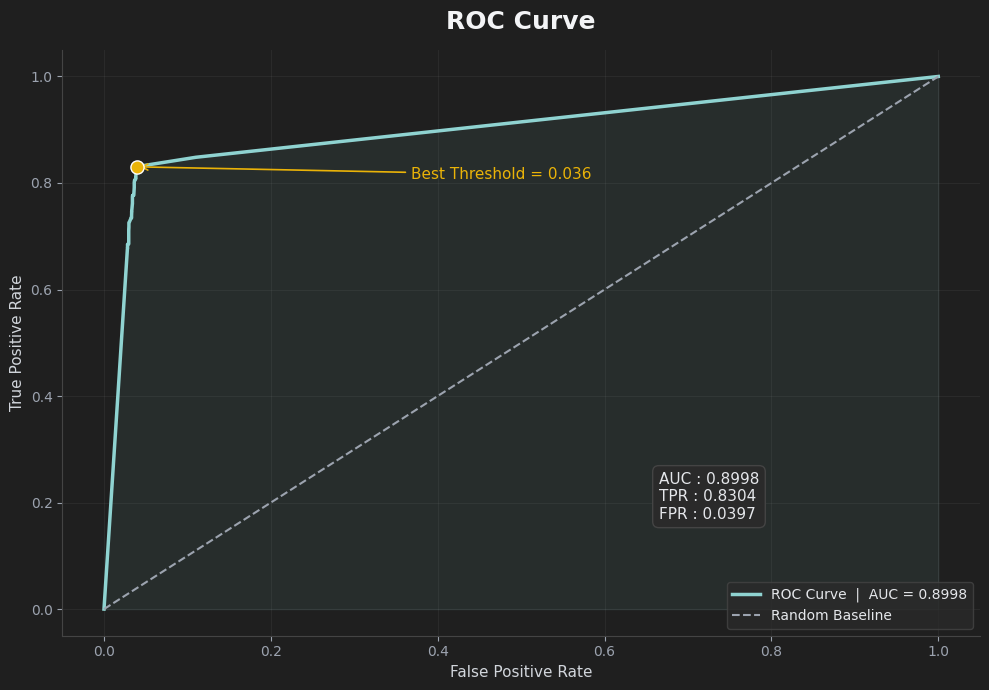

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.style.use("default")

if    hasattr(final_model, "predict_proba"): y_score = final_model.predict_proba(X_test)[:, 1]
else: y_score = final_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

youden_index = tpr - fpr
best_index = youden_index.argmax()

best_threshold = thresholds[best_index]
best_fpr = fpr[best_index]
best_tpr = tpr[best_index]

fig, ax = plt.subplots(figsize = (10, 7))

fig.patch.set_facecolor("#1f1f1f")
ax.set_facecolor("#1f1f1f")

ax.plot(
    fpr,
    tpr,
    linewidth = 2.5,
    color = "#8fd3d1",
    label = f"ROC Curve  |  AUC = {auc_score:.4f}"
)

ax.fill_between(
    fpr,
    tpr,
    alpha = 0.08,
    color = "#8fd3d1"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    linewidth = 1.5,
    color = "#9ca3af",
    label = "Random Baseline"
)

ax.scatter(
    best_fpr,
    best_tpr,
    s = 90,
    color = "#eab308",
    edgecolor = "white",
    linewidth = 1,
    zorder = 5
)

ax.annotate(
    f"Best Threshold = {best_threshold:.3f}",
    xy = (best_fpr, best_tpr),
    xytext = (0.38, 0.78),
    textcoords = "axes fraction",
    arrowprops = dict(
        arrowstyle = "->",
        color = "#eab308",
        linewidth = 1.2
    ),
    fontsize = 11,
    color = "#eab308"
)

ax.text(
    0.65,
    0.20,
    f"AUC : {auc_score:.4f}\n"
    f"TPR : {best_tpr:.4f}\n"
    f"FPR : {best_fpr:.4f}",
    transform = ax.transAxes,
    fontsize = 11,
    color = "#e5e7eb",
    bbox = dict(
        boxstyle = "round,pad = 0.4",
        facecolor = "#2a2a2a",
        edgecolor = "#444"
    )
)

ax.set_title(
    "ROC Curve",
    fontsize = 18,
    fontweight = "bold",
    color = "#f3f4f6",
    pad = 15
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize = 11,
    color = "#d1d5db"
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize = 11,
    color = "#d1d5db"
)

ax.tick_params(axis = "x", colors = "#9ca3af")
ax.tick_params(axis = "y", colors = "#9ca3af")

ax.spines["bottom"].set_color("#444")
ax.spines["left"].set_color("#444")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha = 0.08)

ax.legend(
    facecolor = "#2a2a2a",
    edgecolor = "#444",
    labelcolor = "#e5e7eb",
    loc = "lower right"
)

plt.tight_layout()
plt.show()

In [33]:
all_results = pd.read_csv("all_models_results.csv")
print(all_results.head(10))

          model   C solver class_weight  max_iter  train_acc  test_acc  \
0  DecisionTree NaN    NaN          NaN       NaN   0.996761  0.841954   
1  DecisionTree NaN    NaN          NaN       NaN   0.997587  0.839780   
2  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
3  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
4  RandomForest NaN    NaN     balanced       NaN   0.999079  0.838538   
5  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
6  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
7  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
8  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   
9  DecisionTree NaN    NaN          NaN       NaN   0.995523  0.832017   

        gap  max_depth  min_samples_split  min_samples_leaf criterion  \
0  0.154808       28.0                8.0              11.0   entropy   
1  0.157807       25.0                6

In [34]:
import joblib

joblib.dump(final_model, "intrusion_model.joblib")

print("Model saved")

Model saved
